In [14]:
# k1=k2=1, error = (num sol) - (exact sol)
import numpy as np 
import matplotlib.pyplot as plt
import torch
import time
torch.set_default_dtype(torch.float64)

U0 = lambda z, t: -torch.exp(-z) \
    + 0.5*torch.where(2*t<z, torch.exp(-torch.abs(z-t))*torch.erfc((2*t-z)/torch.sqrt(4*t)), \
        torch.exp(-z**2/(4*t))*torch.special.erfcx(torch.abs(2*t-z)/torch.sqrt(4*t)) ) \
    + 0.5*torch.exp(-z**2/(4*t))*torch.special.erfcx((2*t+z)/torch.sqrt(4*t)) \
    - z*torch.erfc(z/torch.sqrt(4*t)) \
    + 2*torch.sqrt(t/torch.pi)*torch.exp(-z**2/(4*t))

def set_BCs(T):
    T[0]=T[1] # Left boundary
    T[-1]=T[-2]**2/max(T[-3],1e-40) # Right boundary

def solve_two_layer_FTCS(k1, k2, z_dis,Pda,Lz,nz,tf,device):
    # Construct numerical grid
    dz = Lz/nz; z = torch.arange(-0.5, nz+1, device=device)*dz
    # Finite volume, *** z_dis is at a cell boundary ***
    # need one more point at each end, *** size of z = (nz+2) ***

    # Make sure we reach tf in integer number of setps
    dt = 0.5*(dz**2)/max(k1, k2) # need to include k1 and k2 in dt
    nt = int(np.ceil(tf/dt)); dt = tf/nt # need to update dt 
    print(f'nz = {nz}, nt = {nt}; alignment of nt*dt with tf: err = {nt*dt-tf}')
    
    # Find index m such that z[m+1] > z_dis
    m = torch.searchsorted(z, z_dis, right=True).item()-1
    # no need to move a scalar between gpu and cpu?
    # check z[m+1/2]=z_dis?
    print(f'm = {m}, alignment of z[m+1/2] with z_dis: err = {z[m]+0.5*dz-z_dis}')
    
    # Harmonic mean of k at z_dis
    k_interface = 2 * k1 * k2 / (k1 + k2)
    # Precompute kh (effective k at half grid point z_{j+1/2})
    kh = torch.where(z[:-1] < z_dis, k1, k2); kh[m] = k_interface
    # *** size of kh = (nz+1) ***
    # Pytorch will automatically use the device and dtype of z
    
    # Source at internal points, *** size of source = nz ***
    source = Pda * torch.exp(-z[1:-1])

    # Need to pre-allocate T and J
    T = torch.zeros(nz+2, device=device) # size of T = nz+2
    Jh = torch.zeros(nz+1, device=device) # size of k = nz+1
    
    # advance in time steps
    for tstep in range(nt):
        # FTCS update
        set_BCs(T) # start each step by enforcing BCs
        Jh = -kh * (T[1:]-T[:-1])/dz # Flux 
        T[1:-1] = T[1:-1] + dt/dz*(Jh[:-1] - Jh[1:])+dt*source
    set_BCs(T) # at the end enforce BC again
    return z, T

def map_2_grid(z, T, k1, k2, z_dis):
    # Map T to Tg (T at *** regular grid points ***); This mapping is nevessary 
    # because coarse grid and fine grid do not share any common cell centers!!!
    #
    m = torch.searchsorted(z, z_dis, right=True).item()-1
    zg = 0.5*(z[:-1]+z[1:])
    Tg = 0.5*(T[:-1]+T[1:]); Tg[m]=Tg[m]+0.5*(T[m+1]-T[m])*(k2-k1)/(k1+k2)
    return zg, Tg


In [16]:
start = time.perf_counter()

device='cpu'
k1=1.0; k2=1.0; z_dis=1.0; Pda=1.0; tf=2; Lz=8.0; nz_unit=10; 
nz1=int(Lz)*nz_unit;
z1,T1 = solve_two_layer_FTCS(k1,k2,z_dis,Pda,Lz,nz1,tf,device)
zg1,Tg1 = map_2_grid(z1, T1, k1, k2, z_dis)
#
nz2=nz1*2;
z2,T2 = solve_two_layer_FTCS(k1,k2,z_dis,Pda,Lz,nz2,tf,device)
zg2,Tg2 = map_2_grid(z2, T2, k1, k2, z_dis)
#
nz3=nz2*2;
z3,T3 = solve_two_layer_FTCS(k1,k2,z_dis,Pda,Lz,nz3,tf,device)
zg3,Tg3 = map_2_grid(z3, T3, k1, k2, z_dis)
#
nz4=nz3*2;
z4,T4 = solve_two_layer_FTCS(k1,k2,z_dis,Pda,Lz,nz4,tf,device)
zg4,Tg4 = map_2_grid(z4, T4, k1, k2, z_dis)
#
# Error estimates
er_1 = T1-U0(z1, torch.tensor(tf))
er_2 = T2-U0(z2, torch.tensor(tf))
er_3 = T3-U0(z3, torch.tensor(tf))

end = time.perf_counter()
print(f'device = {device}; elapsed time = {end-start:.3f} seconds')


nz = 80, nt = 400; alignment of nt*dt with tf: err = 0.0
m = 10, alignment of z[m+1/2] with z_dis: err = 0.0
nz = 160, nt = 1600; alignment of nt*dt with tf: err = 0.0
m = 20, alignment of z[m+1/2] with z_dis: err = 0.0
nz = 320, nt = 6400; alignment of nt*dt with tf: err = 0.0
m = 40, alignment of z[m+1/2] with z_dis: err = 0.0
nz = 640, nt = 25600; alignment of nt*dt with tf: err = 0.0
m = 80, alignment of z[m+1/2] with z_dis: err = 0.0
device = cpu; elapsed time = 0.749 seconds


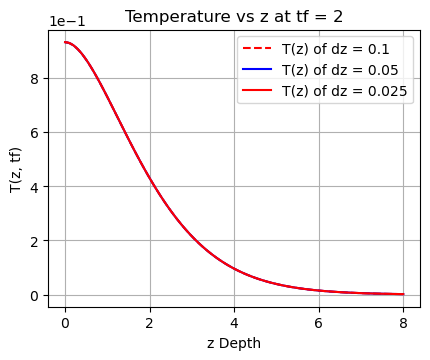

In [19]:
fig1 = plt.figure(figsize=(4.8,3.6))
plt.clf()
plt.plot(zg1.cpu(), Tg1.cpu(), 'r--', label=f'T(z) of dz = {Lz/nz1}')
plt.plot(zg2.cpu(), Tg2.cpu(), 'b-', label=f'T(z) of dz = {Lz/nz2}')
plt.plot(zg3.cpu(), Tg3.cpu(), 'r-', label=f'T(z) of dz = {Lz/nz3}')
plt.xlabel('z Depth')
plt.ylabel(f'T(z, tf)')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.title(f'Temperature vs z at tf = {tf}')
plt.legend()
plt.grid(True)
# plt.savefig('compB.pdf',bbox_inches='tight')
plt.show()

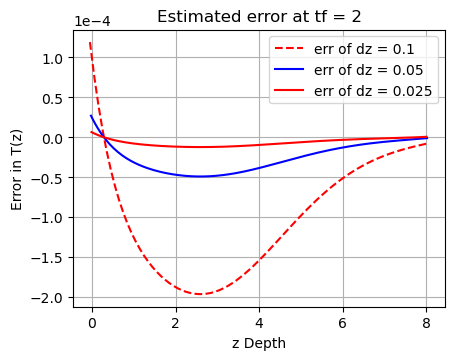

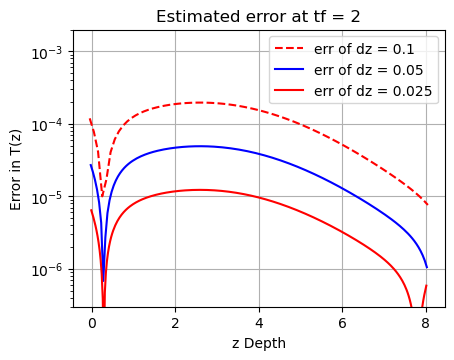

In [21]:

fig2A = plt.figure(figsize=(4.8,3.6))
plt.clf()
plt.plot(z1.cpu(), er_1.cpu(), 'r--', label=f'err of dz = {Lz/nz1}')
plt.plot(z2.cpu(), er_2.cpu(), 'b-', label=f'err of dz = {Lz/nz2}')
plt.plot(z3.cpu(), er_3.cpu(), 'r-', label=f'err of dz = {Lz/nz3}')
plt.xlabel('z Depth')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.ylabel(f'Error in T(z)')
plt.title(f'Estimated error at tf = {tf}')
plt.legend()
plt.grid(True)
# plt.savefig('compB.pdf',bbox_inches='tight')
plt.show()

fig2B= plt.figure(figsize=(4.8,3.6))
plt.clf()
plt.semilogy(z1.cpu(), torch.abs(er_1).cpu(), 'r--', label=f'err of dz = {Lz/nz1}')
plt.semilogy(z2.cpu(), torch.abs(er_2).cpu(), 'b-', label=f'err of dz = {Lz/nz2}')
plt.semilogy(z3.cpu(), torch.abs(er_3).cpu(), 'r-', label=f'err of dz = {Lz/nz3}')
plt.xlabel('z Depth')
plt.ylabel(f'Error in T(z)'); plt.ylim(3e-7,2e-3)
plt.title(f'Estimated error at tf = {tf}')
plt.legend()
plt.grid(True)
# plt.savefig('compB.pdf',bbox_inches='tight')
plt.show()
